# Experiment 1: learning the screened Coulomb kernel in 2D

Three models fit the same screened-Coulomb energies $E[\rho] = \frac{1}{2 N_x N_y}\sum_{r,r'} \rho_r K_{q_s}(r - r') \rho_{r'}$ (von Neumann boundary conditions, DCT basis):

| model | section | what it learns |
|---|---|---|
| **ESL** | 1 | the kernel itself: a linear spectral layer with learnable amplitude and screening momentum $q_s$ |
| **LERN_SR** (SR = short range) | 2 | local reweighting factors $f(x_r) \in [0, 2]$ of the *unscreened* local Coulomb energy; the feature vector $x_r$ holds the densities of nearby sites |
| **LERN_LR** (LR = long range; DM21-like) | 3 | same as LERN_SR, but the feature vector additionally contains the *nonlocal* unscreened Hartree energy |

Set `data_regime` and `qs` below, then run top to bottom. With `flag_train`/`flag_generate_data`
set to `False`, the notebook loads the existing datasets (`DATA2d/`) and checkpoints
(`LearningSC2d_checkpoints/`) and regenerates the training-history exports in
`Results_2D/Experiment_1/`. Checkpoint file names keep the historical prefixes
(`LERN2d_` for LERN_SR, `LERN2d_mod_` for LERN_LR).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import math, os
import pandas as pd
from ewaldnn2d import *

torch.random.manual_seed(1234) # for reproducibility

# Global settings
dtype = torch.float64
device = "cpu"
N_batch = 100
N_epochs = 10000
lr = 1e-1 # we will use a LR scheduler, so this is just an initial value
min_delta = 1e-5 # min change in the monitored quantity to qualify as an improvement
N_pow = 1 # number of local features per grid point
N_train = 1500
N_test = 250
N_val = 250
N_energy_terms = 1 # number of energy terms for the LERN_SR / LERN_LR models
ckpt_dir = "LearningSC2d_checkpoints"
flag_generate_data = False # if True, generate new data; if False, load existing data from disk
flag_train = False         # if True, (re)train models; if False, use existing checkpoints

# grid and basis settings
N_x = 32 # number of grid points in x direction
N_y = N_x # number of grid points in y direction
m_x = torch.arange(0, N_x, dtype=dtype, device=device)             # (N_x,)
m_y = torch.arange(0, N_y, dtype=dtype, device=device)             # (N_y,)
abs_val = torch.sqrt(m_x[:, None]**2 + m_y[None, :]**2)  # (M_x, M_y)
x = torch.linspace(0, 1, N_x, dtype=dtype, device=device)            # (N_x,)
y = torch.linspace(0, 1, N_y, dtype=dtype, device=device)            # (N_y,)
DM_x = torch.cos(torch.pi * torch.outer(m_x, x))                  # (M_x, N_x)
DM_y = torch.cos(torch.pi * torch.outer(m_y, y))                  # (M_y, N_y)
DerDM_x = -torch.pi * m_x[:, None] * torch.sin(torch.pi * torch.outer(m_x, x))  # (M_x, N_x) # derivative of design matrix
DerDM_y = -torch.pi * m_y[:, None] * torch.sin(torch.pi * torch.outer(m_y, y))  # (M_y, N_y) # derivative of design matrix

data_regime = "smooth" # "smooth" or "rough"
if data_regime == "smooth":
    M_cutoff = 10 # maximum harmonic
    std_harm = 2.0 / (1.0 + 0.2 * abs_val)**2 * (abs_val <= M_cutoff).double()  # (M_x, M_y)
elif data_regime == "rough":
    std_harm = 2.0 / (1.0 + 0.0 * abs_val)**2 # (M_x, M_y)
else:
    raise ValueError("regime must be 'smooth' or 'rough'")
std_harm[0, 0] = 0.0 # no uniform density offset

# interaction kernel parameters
qs = 0.0 # screening momentum
amp = 1.0 # amplitude of interaction kernel
kernel_regime = "screened_coulomb"

# screened total energy function (the learning target of all three models)
def E_SC(rho: torch.Tensor, d_rho_x: torch.Tensor, d_rho_y: torch.Tensor, eng_dens_flag: bool = False) -> torch.Tensor:
    return amp * E_int_ms_dct(rho, kernel=kernel_regime, eng_dens_flag=eng_dens_flag, qs=qs)

# unscreened Hartree energy function (the local energy term reweighted by LERN_SR / LERN_LR)
def E_HF(rho: torch.Tensor, d_rho_x: torch.Tensor, d_rho_y: torch.Tensor, eng_dens_flag: bool = False) -> torch.Tensor:
    return amp * E_int_ms_dct(rho, kernel=kernel_regime, eng_dens_flag=eng_dens_flag, qs=0.0)

os.makedirs("Results_2D/Experiment_1", exist_ok=True)

## 1) ESL: linear spectral layer

Learns the amplitude and the screening momentum $q_s$ of the kernel directly; reconstruction
should reach machine precision in either data regime.

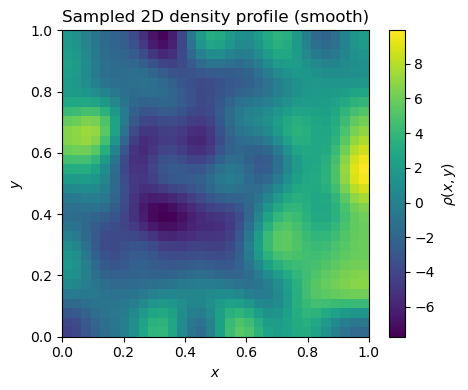

In [2]:
# generate or load the ESL dataset (density profiles + exact screened energies)
if flag_generate_data:
    N_batch_int = 10 # number of density profiles per data generation batch
    torch.manual_seed(1234) # for reproducibility
    rho_train, d_rho_x_train, d_rho_y_train, a_train, targets_train = generate_data_2d(N_train, N_batch_int, E_SC, std_harm=std_harm, DM_x=DM_x, DerDM_x=DerDM_x, DM_y=DM_y, DerDM_y=DerDM_y)
    rho_test, d_rho_x_test, d_rho_y_test, a_test, targets_test = generate_data_2d(N_test, N_batch_int, E_SC, std_harm=std_harm, DM_x=DM_x, DerDM_x=DerDM_x, DM_y=DM_y, DerDM_y=DerDM_y)
    rho_val, d_rho_x_val, d_rho_y_val, a_val, targets_val = generate_data_2d(N_val, N_batch_int, E_SC, std_harm=std_harm, DM_x=DM_x, DerDM_x=DerDM_x, DM_y=DM_y, DerDM_y=DerDM_y)
    os.makedirs("DATA2d", exist_ok=True)
    torch.save(
        {
            "rho_train": rho_train, "d_rho_x_train": d_rho_x_train, "d_rho_y_train": d_rho_y_train, "a_train": a_train, "targets_train": targets_train,
            "rho_val": rho_val, "d_rho_x_val": d_rho_x_val, "d_rho_y_val": d_rho_y_val, "a_val": a_val, "targets_val": targets_val,
            "rho_test": rho_test, "d_rho_x_test": d_rho_x_test, "d_rho_y_test": d_rho_y_test, "a_test": a_test, "targets_test": targets_test,
            "data_regime": data_regime, "kernel_regime": kernel_regime,
        },
        f"DATA2d/dataset_{data_regime}_{kernel_regime}_{qs}_{amp}_{N_x}_{N_y}.pt",
    )
else:
    data = torch.load(f"DATA2d/dataset_{data_regime}_{kernel_regime}_{qs}_{amp}_{N_x}_{N_y}.pt")
    rho_train, targets_train = data["rho_train"], data["targets_train"]
    rho_test, targets_test = data["rho_test"], data["targets_test"]
    rho_val, targets_val = data["rho_val"], data["targets_val"]

features_train = generate_loc_features_rs(rho_train, N_pow=N_pow)  # (N_train, N_x, N_y, N_feat)
features_test  = generate_loc_features_rs(rho_test, N_pow=N_pow)   # (N_test, N_x, N_y, N_feat)
features_val   = generate_loc_features_rs(rho_val, N_pow=N_pow)    # (N_val, N_x, N_y, N_feat)

# Normalize features
mean_feat, std_feat = compute_normalization_stats(features_train)
features_train_norm = normalize_features(features_train, mean_feat, std_feat)
features_test_norm = normalize_features(features_test, mean_feat, std_feat)
features_val_norm = normalize_features(features_val, mean_feat, std_feat)

# Normalize targets
E_mean = targets_train.mean()
E_std = targets_train.std()
targets_train_norm = (targets_train - E_mean) / E_std
targets_test_norm = (targets_test - E_mean) / E_std
targets_val_norm = (targets_val - E_mean) / E_std

# Loaders
train_loader = DataLoader(TensorDataset(features_train_norm, targets_train_norm), batch_size=N_batch, shuffle=True,  drop_last=False)
val_loader   = DataLoader(TensorDataset(features_val_norm,   targets_val_norm),   batch_size=N_batch, shuffle=False, drop_last=False)
test_loader  = DataLoader(TensorDataset(features_test_norm,  targets_test_norm),  batch_size=N_batch, shuffle=False, drop_last=False)

# visualize a sampled density profile
rho_batch, _, _ , a_batch = sample_density_batch(N_batch, std_harm=std_harm, DM_x=DM_x, DerDM_x=DerDM_x, DM_y=DM_y, DerDM_y=DerDM_y)
plt.figure(figsize=(5, 4))
im = plt.imshow(
    rho_batch[0].detach().cpu().numpy().T,  # transpose so x is horizontal, y vertical
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="equal"
)
plt.colorbar(im, label=r"$\rho(x,y)$")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(f"Sampled 2D density profile ({data_regime})")
plt.tight_layout()
plt.show()

In [3]:
run_name_ESL = f"rs_dct_kernel_" + data_regime + '_' + kernel_regime + f"_{qs}_{amp}_{N_x}_{N_y}"

if flag_train:
    torch.manual_seed(1234) # for reproducibility
    model = DCTKernelEnergyNN(
            N_x=N_x,
            N_y=N_y,
            learning_mode="dct_coulomb",
            mean_feat=mean_feat,
            std_feat=std_feat,
            E_mean=E_mean,
            E_std=E_std,
        ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Reduce LR when val loss plateaus
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=50, cooldown=2, min_lr=1e-6
    )

    hist, best_epoch = train_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        max_epochs=N_epochs,
        patience=500,
        min_delta=min_delta,
        ckpt_dir=ckpt_dir,
        run_name=run_name_ESL,
        learning_regime="dct_coulomb",
        N_x=N_x,
        N_y=N_y,
        device=device,
    )

   epoch  train_loss  val_loss
0      1    2.704760  2.681123
1      2    1.055132  0.482778
2      3    0.225261  0.215940
3      4    0.086663  0.075759
4      5    0.060654  0.068554
Best validation loss: 4.0685559074233385e-08


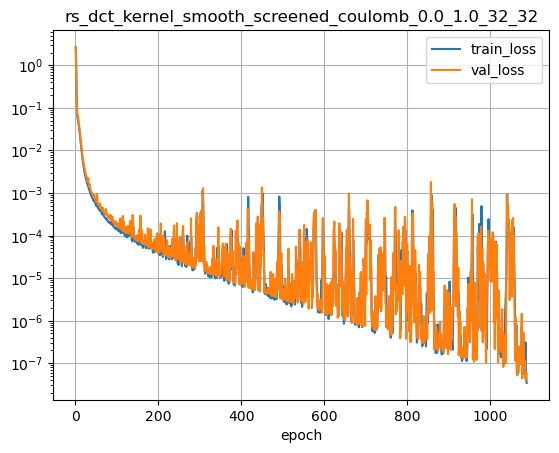

In [4]:
hist_df = pd.read_csv(ckpt_dir + f"/{run_name_ESL}_history.csv")
print(hist_df.head())
hist_df.plot(x="epoch", y=["train_loss", "val_loss"], logy=True, grid=True, title=run_name_ESL)

data = np.column_stack([
    hist_df["epoch"].to_numpy(),
    hist_df["train_loss"].to_numpy(),
    hist_df["val_loss"].to_numpy(),
])
np.savetxt(f"Results_2D/Experiment_1/hist_ESL_{data_regime}_{qs}.txt", data)
print(f"Best validation loss: {min(data[:, 2])}")

Learned Screened Coulomb Kernel:
Amplitude: Parameter containing:
tensor([1.0008], requires_grad=True)  (true: 1.0 )
q_s: tensor(0.0031)  (true: 0.0 )


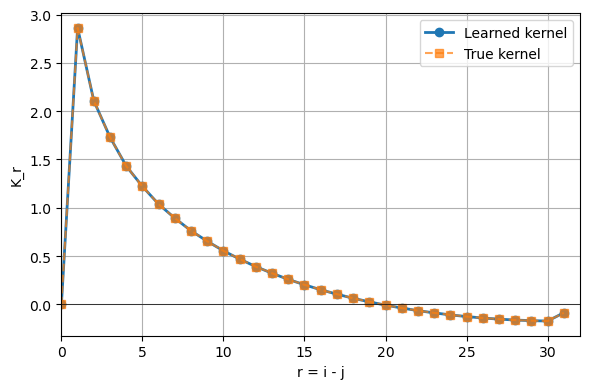

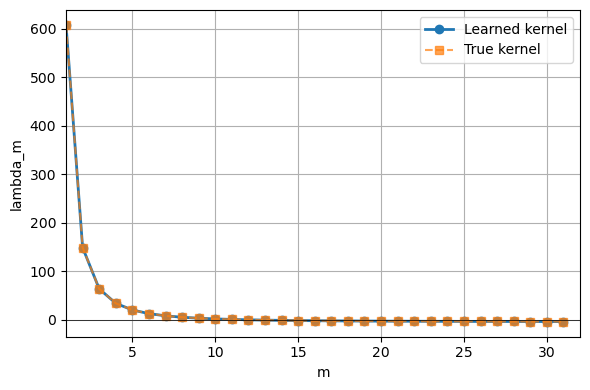

In [5]:
model, normalization, epoch, val_loss = load_checkpoint(
        ckpt_dir + f"/{run_name_ESL}_best.pt",
        DCTKernelEnergyNN,
        device=device
    )

print("Learned Screened Coulomb Kernel:")
with torch.no_grad():
    qs_learned = F.softplus(model.nonlocal_kernel.raw_qs)
    amp_learned = model.nonlocal_kernel.amp
    print("Amplitude:", amp_learned, " (true:", amp, ")")
    print("q_s:", qs_learned, " (true:", qs, ")")
    lam_K_full = (amp_learned * Lam_K_Coulomb(model.nonlocal_kernel.q_vals, qs=qs_learned)).to(device=device, dtype=dtype)  # (N_x, N_y)

# true kernel on the same momentum grid
m_vals = torch.arange(0, N_x, device=device, dtype=dtype)
n_vals = torch.arange(0, N_y, device=device, dtype=dtype)
q_x = torch.pi * m_vals.view(-1, 1) / (N_x - 1)
q_y = torch.pi * n_vals.view(1, -1) / (N_y - 1)
q_vals = torch.sqrt(q_x**2 + q_y**2)  # (N_x, N_y)
lam_K_true = (amp * Lam_K_Coulomb(q_vals, qs=qs)).to(device=device, dtype=dtype)  # (N_x, N_y)
k_true = kernel_from_eigenvals_dct(lam_K_true)
K_true_np = k_true.detach().cpu().numpy()

lam_K_full[0, 0] = lam_K_true[0, 0] # enforce the physical zero mode
k_full = kernel_from_eigenvals_dct(lam_K_full)
k_full_np = k_full.detach().cpu().numpy()

r_grid = np.arange(0, N_x)
plt.figure(figsize=(6,4))
plt.plot(r_grid, k_full_np[:, 0], 'o-', label='Learned kernel', linewidth=2)
plt.plot(r_grid, K_true_np[:, 0], 's--', label='True kernel', alpha=0.7)
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel("r = i - j")
plt.ylabel("K_r")
plt.xlim(0, 32)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(r_grid, lam_K_full[:, 0], 'o-', label='Learned kernel', linewidth=2)
plt.plot(r_grid, lam_K_true[:, 0], 's--', label='True kernel', alpha=0.7)
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel("m")
plt.ylabel("lambda_m")
plt.xlim(1, 32)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2) LERN_SR: local reweighting with short-range features

The model multiplies the *unscreened* local Coulomb energy by a learned factor
$f(x_r) \in [0, 2]$, where $x_r$ holds the densities of the site and its 4 (`R_feat = 1.0`)
or 8 (`R_feat = 1.5`) neighbours. For $q_s = 0$ all factors are 1 and the fit is near-perfect;
for $q_s > 0$ purely local reweighting cannot capture screening.

Both LERN sections share the dataset below (profiles, local unscreened Hartree energy
densities, exact screened energies) and the helper functions.

In [6]:
# generate or load the LERN dataset (shared by LERN_SR and LERN_LR)
if flag_generate_data:
    N_batch_int = 10 # number of density profiles per data generation batch
    torch.manual_seed(1234) # for reproducibility
    rho_train, d_rho_x_train, d_rho_y_train, a_train, E_loc_HF_train, E_SC_train = generate_SC_data_2d(N_train, N_batch_int, E_HF, E_SC, std_harm=std_harm, DM_x=DM_x, DerDM_x=DerDM_x, DM_y=DM_y, DerDM_y=DerDM_y)
    rho_test, d_rho_x_test, d_rho_y_test, a_test, E_loc_HF_test, E_SC_test = generate_SC_data_2d(N_test, N_batch_int, E_HF, E_SC, std_harm=std_harm, DM_x=DM_x, DerDM_x=DerDM_x, DM_y=DM_y, DerDM_y=DerDM_y)
    rho_val, d_rho_x_val, d_rho_y_val, a_val, E_loc_HF_val, E_SC_val = generate_SC_data_2d(N_val, N_batch_int, E_HF, E_SC, std_harm=std_harm, DM_x=DM_x, DerDM_x=DerDM_x, DM_y=DM_y, DerDM_y=DerDM_y)
    os.makedirs("DATA2d", exist_ok=True)
    torch.save(
        {
            "rho_train": rho_train, "d_rho_x_train": d_rho_x_train, "d_rho_y_train": d_rho_y_train, "a_train": a_train, "E_loc_HF_train": E_loc_HF_train, "E_SC_train": E_SC_train,
            "rho_val": rho_val, "d_rho_x_val": d_rho_x_val, "d_rho_y_val": d_rho_y_val, "a_val": a_val, "E_loc_HF_val": E_loc_HF_val, "E_SC_val": E_SC_val,
            "rho_test": rho_test, "d_rho_x_test": d_rho_x_test, "d_rho_y_test": d_rho_y_test, "a_test": a_test, "E_loc_HF_test": E_loc_HF_test, "E_SC_test": E_SC_test,
            "data_regime": data_regime, "kernel_regime": kernel_regime,
        },
        f"DATA2d/LERN_dataset_{data_regime}_{kernel_regime}_{qs}_{amp}_{N_x}_{N_y}.pt",
    )
else:
    data = torch.load(f"DATA2d/LERN_dataset_{data_regime}_{kernel_regime}_{qs}_{amp}_{N_x}_{N_y}.pt")
    rho_train, E_loc_HF_train, E_SC_train = data["rho_train"], data["E_loc_HF_train"], data["E_SC_train"]
    rho_test, E_loc_HF_test, E_SC_test = data["rho_test"], data["E_loc_HF_test"], data["E_SC_test"]
    rho_val, E_loc_HF_val, E_SC_val = data["rho_val"], data["E_loc_HF_val"], data["E_SC_val"]

# Normalize targets (shared by both LERN models)
E_mean = E_SC_train.mean()
E_std = E_SC_train.std()

n_hidden_list = [1, 2, 3, 4]
n_neurons_list = [8, 16, 32, 64]


def build_features(rho, E_loc_HF, R_feat, add_HF, stats=None):
    """Local features (densities of the site and its neighbours within R_feat), for LERN_LR
    additionally the nonlocal unscreened Hartree energy as a feature (appended before
    normalization); the raw Hartree energy density is always appended last as the energy
    term reweighted by the model. Returns (packed features, normalization stats, N_feat)."""
    f = extend_features_neighbors_2d(generate_loc_features_rs(rho, N_pow=N_pow), R=R_feat)
    if add_HF:
        f = torch.cat([f, E_loc_HF], dim=-1)
    if stats is None:
        stats = compute_normalization_stats(f)
    return torch.cat([normalize_features(f, *stats), E_loc_HF], dim=-1), stats, f.shape[-1]


def run_name_for(prefix, N_feat, n_hidden, n_neurons, seed):
    return f"{prefix}" + data_regime + '_' + kernel_regime + f"_{qs}_{amp}_{N_x}_{N_y}_{N_feat}_{N_energy_terms}_{n_hidden}_{n_neurons}_{seed}"


def train_grid(prefix, train_loader, val_loader, N_feat, mean_feat, std_feat):
    """Hyperparameter grid search: 4 depths x 4 widths x 3 seeds (N_feat is set by R_feat
    in the feature-building cell; run with both R_feat values to cover the full grid)."""
    for n_hidden in n_hidden_list:
        for n_neurons in n_neurons_list:
            for seed in range(3):
                torch.manual_seed(1234 + seed)
                run_name = run_name_for(prefix, N_feat, n_hidden, n_neurons, seed)
                print(f"Training model: n_hidden={n_hidden}, n_neurons={n_neurons}, seed={seed}")
                model = LERN2d(
                        N_x=N_x, N_y=N_y, N_energy_terms=N_energy_terms, N_feat=N_feat,
                        n_hidden=n_hidden, n_neurons=n_neurons,
                        mean_feat=mean_feat, std_feat=std_feat, E_mean=E_mean, E_std=E_std,
                    ).to(device=device, dtype=dtype)
                optimizer = optim.Adam(model.parameters(), lr=lr)
                scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=50, cooldown=2, min_lr=1e-6)
                train_with_early_stopping(
                    model=model, train_loader=train_loader, val_loader=val_loader,
                    criterion=nn.MSELoss(), optimizer=optimizer, scheduler=scheduler,
                    max_epochs=N_epochs, patience=100, min_delta=min_delta,
                    ckpt_dir=ckpt_dir, run_name=run_name, learning_regime="LERN2d",
                    N_x=N_x, N_y=N_y, device=device)


def select_best(prefix, N_feat_list):
    """Best checkpoint over the full grid (depth x width x seed x feature set)."""
    best_val, best_run, best_N_feat = math.inf, None, None
    for n_hidden in n_hidden_list:
        for n_neurons in n_neurons_list:
            for seed in range(3):
                for N_feat in N_feat_list:
                    run_name = run_name_for(prefix, N_feat, n_hidden, n_neurons, seed)
                    _, _, _, val_loss = load_checkpoint(ckpt_dir + f"/{run_name}_best.pt", LERN2d, device=device)
                    if val_loss < best_val:
                        best_val, best_run, best_N_feat = val_loss, run_name, N_feat
    print(f"Overall best model: {best_run}  (val_loss={best_val:.10f})")
    return best_run, best_N_feat


def plot_history_and_export(run_name, out_file):
    hist_df = pd.read_csv(ckpt_dir + f"/{run_name}_history.csv")
    hist_df.plot(x="epoch", y=["train_loss", "val_loss"], logy=True, grid=True, title=run_name)
    data = np.column_stack([hist_df["epoch"].to_numpy(), hist_df["train_loss"].to_numpy(), hist_df["val_loss"].to_numpy()])
    np.savetxt(out_file, data)
    print(f"Best validation loss: {min(data[:, 2])}  ->  {out_file}")


def show_factors(run_name, N_feat_best, add_HF, k=4):
    """Reload the best checkpoint, rebuild matching test features (N_feat fixes R_feat;
    stats come from the checkpoint) and show the density, the learned local factors
    f(x, y) for test sample k, and their histogram pooled over the test set."""
    model, normalization, _, _ = load_checkpoint(ckpt_dir + f"/{run_name}_best.pt", LERN2d, device=device)
    model = model.to(device=device, dtype=dtype)
    R_feat_best = 1.0 if N_feat_best == (6 if add_HF else 5) else 1.5
    f_norm, _, _ = build_features(rho_test, E_loc_HF_test, R_feat_best, add_HF,
                                  (normalization["mean_feat"], normalization["std_feat"]))
    with torch.no_grad():
        factors = model.local_nn(f_norm[..., :N_feat_best])    # (N_test, N_x, N_y, N_energy_terms)
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
    for ax, img, lab in ((axes[0], rho_test[k], r"$\rho(x,y)$"),
                         (axes[1], factors[k, ..., 0], r"$f(x,y)$")):
        im = ax.imshow(img.detach().cpu().numpy().T, origin="lower", extent=[0, 1, 0, 1], aspect="equal")
        fig.colorbar(im, ax=ax, label=lab)
        ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$y$")
    axes[0].set_title(f"test density profile ({data_regime})")
    axes[1].set_title("learned local factors")
    axes[2].hist(factors.reshape(-1).detach().cpu().numpy(), bins=np.linspace(0.0, 2.0, 101), density=True, alpha=0.8)
    axes[2].set_xlim(-0.1, 2.1); axes[2].set_ylim(0, 10)
    axes[2].set_xlabel(r"local factor value $f(x,y)$"); axes[2].set_ylabel("probability density")
    axes[2].set_title(f"factors pooled over {len(rho_test)} test samples")
    plt.tight_layout(); plt.show()
    return model

In [7]:
# LERN_SR features and loaders (checkpoint prefix "LERN2d_" predates the renaming)
R_feat = 1.5 # radius for neighbor feature extension: 1.0 (4 neighbors) or 1.5 (8 neighbors)
features_train_norm, stats, N_feat = build_features(rho_train, E_loc_HF_train, R_feat, add_HF=False)
features_val_norm, _, _ = build_features(rho_val, E_loc_HF_val, R_feat, add_HF=False, stats=stats)
mean_feat, std_feat = stats
print(f"Number of local features per grid point: {N_feat}")

train_loader = DataLoader(TensorDataset(features_train_norm, (E_SC_train - E_mean) / E_std), batch_size=N_batch, shuffle=True,  drop_last=False)
val_loader   = DataLoader(TensorDataset(features_val_norm,   (E_SC_val - E_mean) / E_std),   batch_size=N_batch, shuffle=False, drop_last=False)

if flag_train:
    train_grid("LERN2d_", train_loader, val_loader, N_feat, mean_feat, std_feat)

Number of local features per grid point: 9


Overall best model: LERN2d_smooth_screened_coulomb_0.0_1.0_32_32_9_1_4_8_2  (val_loss=0.0000000000)
Best validation loss: 5.97419750224944e-12  ->  Results_2D/Experiment_1/LERN_SR_performance_smooth_0.0.txt


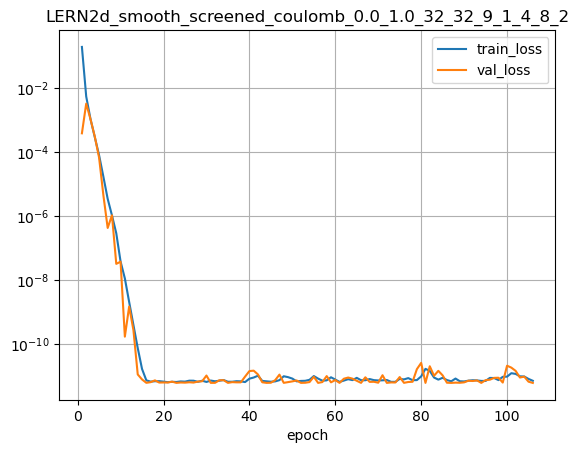

In [8]:
run_name_SR, N_feat_SR = select_best("LERN2d_", N_feat_list=[5, 9])
plot_history_and_export(run_name_SR, f"Results_2D/Experiment_1/LERN_SR_performance_{data_regime}_{qs}.txt")

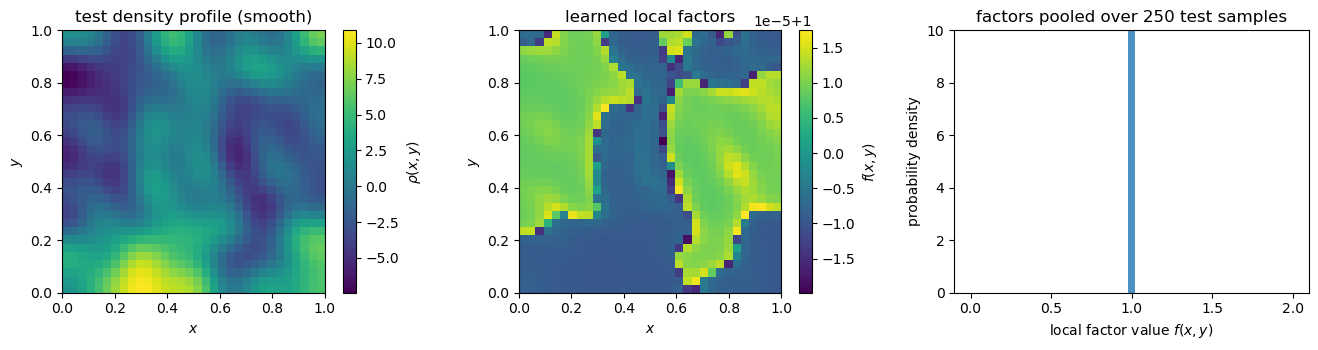

In [9]:
model_SR = show_factors(run_name_SR, N_feat_SR, add_HF=False)

## 3) LERN_LR: local reweighting with a long-range feature (DM21-like)

Identical to LERN_SR, except the feature vector additionally contains the **nonlocal
unscreened Hartree energy** - the DM21-like architectural change: the model is still a
local reweighting of the local Hartree energy density, but its input now carries nonlocal
information.

In [10]:
# LERN_LR features and loaders (checkpoint prefix "LERN2d_mod_" predates the renaming)
R_feat = 1.5 # radius for neighbor feature extension: 1.0 (4 neighbors) or 1.5 (8 neighbors)
features_train_norm, stats, N_feat = build_features(rho_train, E_loc_HF_train, R_feat, add_HF=True)
features_val_norm, _, _ = build_features(rho_val, E_loc_HF_val, R_feat, add_HF=True, stats=stats)
mean_feat, std_feat = stats
print(f"Number of local features per grid point: {N_feat}")

train_loader = DataLoader(TensorDataset(features_train_norm, (E_SC_train - E_mean) / E_std), batch_size=N_batch, shuffle=True,  drop_last=False)
val_loader   = DataLoader(TensorDataset(features_val_norm,   (E_SC_val - E_mean) / E_std),   batch_size=N_batch, shuffle=False, drop_last=False)

if flag_train:
    train_grid("LERN2d_mod_", train_loader, val_loader, N_feat, mean_feat, std_feat)

Number of local features per grid point: 10


Overall best model: LERN2d_mod_smooth_screened_coulomb_0.0_1.0_32_32_10_1_3_8_1  (val_loss=0.0000000000)
Best validation loss: 4.3159290700185686e-11  ->  Results_2D/Experiment_1/LERN_LR_performance_smooth_0.0.txt


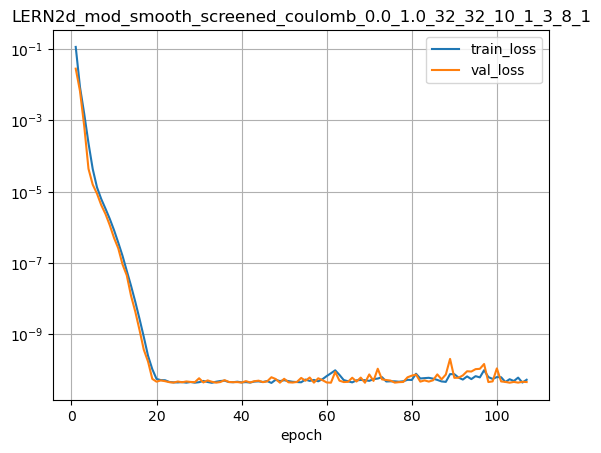

In [11]:
run_name_LR, N_feat_LR = select_best("LERN2d_mod_", N_feat_list=[6, 10])
plot_history_and_export(run_name_LR, f"Results_2D/Experiment_1/LERN_LR_performance_{data_regime}_{qs}.txt")

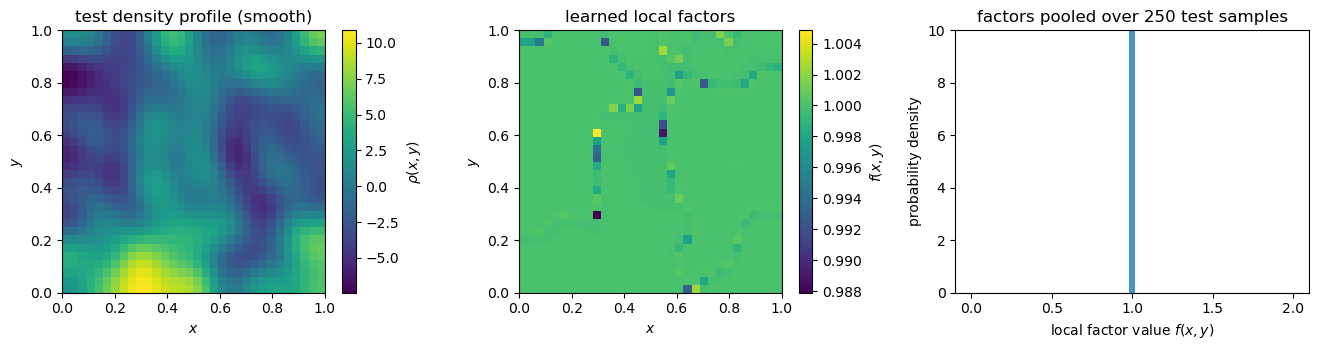

In [12]:
model_LR = show_factors(run_name_LR, N_feat_LR, add_HF=True)